## Imports & Dependencies
Loads all standard libraries (`os`, `re`, `json`, `pandas`, `numpy`, etc.) and initialises environment variables from a `.env` file using `python-dotenv`.

In [1]:
# =========================
# 1. INSTALLS / IMPORTS
# =========================
from __future__ import annotations

import os
import re
import json
import math
import uuid
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from dataclasses import dataclass, field, asdict
from collections import defaultdict

import pandas as pd
import numpy as np

from dotenv import load_dotenv

load_dotenv()

True

## Global Configuration
Defines key paths (`DATA_ROOT`, `OUTPUT_ROOT`), the supported file extensions for claim documents, valid package codes, decision labels (`PASS`, `CONDITIONAL`, `FAIL`), and reads API credentials from environment variables.

In [2]:
# =========================
# 2. CONFIG
# =========================

DATA_ROOT = Path("/Users/apple/Desktop/Hackathon-/Claims")         # input claims folder
OUTPUT_ROOT = Path("./outputs")    # json/csv/html outputs
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SUPPORTED_EXTENSIONS = {".pdf", ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

PACKAGE_CODES = ["MG064A", "SG039C", "MG006A", "SB039A"]

DECISION_PASS = "PASS"
DECISION_CONDITIONAL = "CONDITIONAL"
DECISION_FAIL = "FAIL"

CLIENT_ID = os.getenv("CLIENT_ID")
CLINENT_SECRET = os.getenv("CLINENT_SECRET")

## NHA API Client
Implements `NHAclient`, a thin HTTP wrapper around the NHA hackathon LLM proxy. It fetches a bearer token on construction, sends chat-completion requests, and transparently refreshes the token when a 401 or expiry error is detected.

In [3]:
# =========================
# 2.1 CONFIG (MODELS)
# =========================

import json
import logging
import httpx

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


class NHAclient:
    TOKEN_URL = "https://aaehackathon.nhaad.in/controlplane/iudx/v2/auth/token"
    COMPLETIONS_URL = "https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions"

    def __init__(self, client_id: str, client_secret: str):
        self.id = client_id
        self.secret = client_secret
        self.token = self._get_token()

    def _get_token(self) -> str:
        logger.info("Fetching new auth token...")
        resp = httpx.post(
            self.TOKEN_URL,
            headers={
                "clientId": self.id,
                "clientSecret": self.secret
            },
            follow_redirects=True
        )
        resp.raise_for_status()
        data = resp.json()
        
        result = data.get("result", {})
        token = result.get("access_token") or result.get("token")
        if not token:
            raise ValueError(f"Token not found in response: {data}")
        
        logger.info("Auth token obtained successfully")
        return token

    def completion(self, model: str, messages: list, **kwargs) -> dict:
        payload = {
            "model": model,
            "messages": messages,
            "auth_token": self.token,
            **kwargs
        }

        with httpx.Client(timeout=None) as client:
            resp = client.post(self.COMPLETIONS_URL, json=payload)
            
            if self._is_token_expired(resp):
                logger.info("Token expired, refreshing token and retrying...")
                self.token = self._get_token()
                payload["auth_token"] = self.token
                resp = client.post(self.COMPLETIONS_URL, json=payload)
            
            return resp.json()

    def _is_token_expired(self, resp: httpx.Response) -> bool:
        if resp.status_code == 401:
            return True
        
        if resp.status_code == 200:
            try:
                data = resp.json()
                if isinstance(data, dict):
                    error = data.get("error", {})
                    if isinstance(error, dict):
                        message = error.get("message", "")
                        if "expired" in message.lower() or "token" in message.lower():
                            return True
            except Exception:
                pass
        
        return False

## Client Smoke Test
Instantiates `NHAclient` and fires a quick single-turn completion (`"Say hello in 3 words"`) to verify that authentication and the completion endpoint are working before running the full pipeline.

In [4]:
# Testing the Model Client
def main():
    client = NHAclient(
        client_id=CLIENT_ID,
        client_secret=CLINENT_SECRET
    )
    
    resp = client.completion(
        model="Gemma 3 4B",
        messages=[{"role": "user", "content": [{"type": "text", "text" : "Say hello in 3 words"}]}],
        metadata={
            "problem_statement":1
        }
    )
    print(resp)

main()

# response = nc.completion(
#     model="Gemma 3 4B", #use one of the models
#     messages=[
#         {
#             "role": "user",
#             "content": [
#                 {"type": "image_url", "image_url": {"url": data_url}},
#                 {"type": "text", "text": "What do you see"},
#             ],
#         }
#     ],
#     metadata={
#             "problem_statement":1

2026-04-24 10:35:33,494 - INFO - Fetching new auth token...
2026-04-24 10:35:33,851 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/controlplane/iudx/v2/auth/token "HTTP/1.1 200 OK"
2026-04-24 10:35:33,855 - INFO - Auth token obtained successfully
2026-04-24 10:35:34,194 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


{'id': 'chatcmpl-12f23569-9f5f-4bda-bb96-49259764e843', 'created': 1777007134, 'model': 'google.gemma-3-4b-it', 'object': 'chat.completion', 'system_fingerprint': None, 'choices': [{'finish_reason': 'stop', 'index': 0, 'message': {'content': 'Hello there, friend!', 'role': 'assistant', 'tool_calls': None, 'function_call': None}}], 'usage': {'completion_tokens': 6, 'prompt_tokens': 15, 'total_tokens': 21, 'completion_tokens_details': {'reasoning_tokens': 0, 'text_tokens': 6}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None, 'video_tokens': None, 'cache_creation_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0}}


## Output Schemas per Package
Declares `PACKAGE_SCHEMAS`, a dict that lists the exact output column names expected for each of the four PM-JAY packages (`MG064A`, `SG039C`, `MG006A`, `SB039A`). Also defines `KEY_ALIASES` to normalise variant S3-link key names to a single canonical form.

In [5]:
# =========================
# 3. OUTPUT SCHEMAS
# =========================
# These are the exact expected keys per package, based on the provided examples.

PACKAGE_SCHEMAS = {
    "MG064A": [
        "case_id", "link", "procedure_code", "page_number",
        "clinical_notes", "cbc_hb_report", "indoor_case",
        "treatment_details", "post_hb_report", "discharge_summary",
        "severe_anemia", "common_signs", "significant_signs",
        "life_threatening_signs", "extra_document", "document_rank"
    ],
    "SG039C": [
        "case_id", "S3_link/DocumentName", "procedure_code", "page_number",
        "clinical_notes", "usg_report", "lft_report", "operative_notes",
        "pre_anesthesia", "discharge_summary", "photo_evidence",
        "histopathology", "clinical_condition", "usg_calculi",
        "pain_present", "previous_surgery", "extra_document", "document_rank"
    ],
    "MG006A": [
        "case_id", "S3_link/DocumentName", "procedure_code", "page_number",
        "clinical_notes", "investigation_pre", "pre_date", "vitals_treatment",
        "investigation_post", "post_date", "discharge_summary", "poor_quality",
        "fever", "symptoms", "extra_document", "document_rank"
    ],
    "SB039A": [
        "case_id", "link", "procedure_code", "page_number",
        "clinical_notes", "xray_ct_knee", "indoor_case", "operative_notes",
        "implant_invoice", "post_op_photo", "post_op_xray", "discharge_summary",
        "doa", "dod", "arthritis_type", "post_op_implant_present",
        "age_valid", "extra_document", "document_rank"
    ],
}

KEY_ALIASES = {
    "S3_link": "link",
    "s3_link": "link",
    "S3_link/DocumentName": "link",
}

## Core Data Models
Defines lightweight `@dataclass` structures used throughout the pipeline: `OCRLine` (a single OCR text span with bounding box and confidence), `PageResult` (all extracted data for one document page), `TimelineEvent` (a dated clinical event), and `ClaimDecision` (the final adjudication output per case).

In [6]:
# =========================
# 4. DATA MODELS
# =========================

@dataclass
class OCRLine:
    text: str
    bbox: Optional[List[int]] = None
    confidence: Optional[float] = None

@dataclass
class PageResult:
    case_id: str
    file_name: str
    page_number: int
    extracted_text: str = ""
    ocr_lines: List[OCRLine] = field(default_factory=list)
    doc_type: str = "unknown"
    doc_type_confidence: float = 0.0
    visual_tags: Dict[str, Any] = field(default_factory=dict)
    entities: Dict[str, Any] = field(default_factory=dict)
    quality: Dict[str, Any] = field(default_factory=dict)
    output_row: Dict[str, Any] = field(default_factory=dict)
    evidence: Dict[str, Any] = field(default_factory=dict)

@dataclass
class TimelineEvent:
    sequence: int
    event_type: str
    date: Optional[str]
    source_document: str
    temporal_validity: str
    evidence: Dict[str, Any] = field(default_factory=dict)

@dataclass
class ClaimDecision:
    case_id: str
    package_code: str
    decision: str
    confidence: float
    reasons: List[str]
    missing_documents: List[str] = field(default_factory=list)
    rule_flags: List[str] = field(default_factory=list)
    timeline_flags: List[str] = field(default_factory=list)

# 1. INGEST CLAIM FILES


## Case File Discovery
`iter_case_files` recursively lists all supported image/PDF files inside a case folder. `discover_cases` iterates over all subdirectories under `DATA_ROOT` and returns a `{case_id: [file_paths]}` dict.

In [7]:
# =========================
# 1. INGEST CLAIM FILES
# =========================

def iter_case_files(case_dir: Path) -> List[Path]:
    sorted_list = sorted([
        p for p in case_dir.rglob("*") if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS])

    return sorted_list
    

def discover_cases(data_root: Path) -> Dict[str, List[Path]]:
    cases = {}
    for case_dir in sorted(data_root.iterdir()):
        if case_dir.is_dir():
            files = iter_case_files(case_dir)
            if files:
                cases[case_dir.name] = files
    return cases

## Run Case Discovery
Calls `discover_cases` on the configured data root and prints the discovered case IDs so you can verify the folder structure was read correctly.

In [8]:
cases = discover_cases(DATA_ROOT)
print(cases.keys())

dict_keys(['MG006A', 'MG064A', 'SB039A', 'SG039C'])


# 2. SPLIT PDFS/IMAGES INTO PAGES

## PDF & Image → Page Splitter
`extract_pages` converts a PDF to a list of PIL images (one per page at 150 DPI via `pdf2image`) or wraps a single image file in the same format. Returns a list of dicts with `page_number`, `image`, and `file_name`.

In [9]:
# =========================
# 2. SPLIT PDFS/IMAGES INTO PAGES
# =========================

from pdf2image import convert_from_path
from PIL import Image

def extract_pages(file_path):
    pages = []
    suffix = file_path.suffix.lower()

    if suffix == ".pdf":
        try:
            images = convert_from_path(str(file_path), dpi=150)
            for page_num, img in enumerate(images, start=1):
                pages.append({
                    "page_number": page_num,
                    "image": img,
                    "file_name": file_path.name
                })
        except Exception as e:
            print(f"[WARN] Failed to process PDF {file_path.name}: {e}")
    else:
        try:
            img = Image.open(str(file_path))
            img.load()
            pages.append({"page_number": 1, "image": img, "file_name": file_path.name})
        except Exception as e:
            print(f"[WARN] Failed to open image {file_path.name}: {e}")

    return pages

## Extract Pages for a Case
Iterates over all files for the `MG006A` case, extracts individual pages, and prints each page's dimensions as a quick sanity check.

In [10]:
CASE_ID = list(cases.keys())
print(CASE_ID)
all_pages = []

for f in cases["MG006A"]:
    all_pages.extend(extract_pages(f))

for p in all_pages:
    print(f"  [{p['page_number']}] {p['file_name']} → {p['image'].size}") # base64

['MG006A', 'MG064A', 'SB039A', 'SG039C']
  [1] 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf → (1241, 1754)
  [2] 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf → (1241, 1754)
  [3] 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf → (1241, 1754)
  [4] 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf → (1241, 1754)
  [1] 000590__CMJAY_TR_CMJAY_2025_R3_1022010623__36acf382-6069-49c4-b705-a1c62a644a67.jpg → (1161, 1600)
  [1] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [2] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [3] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [4] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [5] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [6] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [7] 000591__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDAM.pdf → (1241, 1754)
  [8] 000591__CMJAY_TR_C

# 3. OCR EACH PAGE

## Base64 Imports
Imports `base64` and `io`, needed to encode PIL images as base64 strings before sending them to the vision-language model.

In [11]:
import base64
import io

## PIL-to-Base64 Helper
`pil_to_base64` serialises a PIL image to a PNG byte buffer and returns it as a base64-encoded UTF-8 string — the format expected by the VLM API's `image_url` content type.

In [12]:
def pil_to_base64(image) -> str:
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

## Instantiate API Client
Creates the shared `NHAclient` instance (using credentials from `.env`) that all subsequent OCR and classification calls will reuse.

In [13]:
client = NHAclient(
    client_id=CLIENT_ID,
    client_secret=CLINENT_SECRET
)

2026-04-24 10:36:21,245 - INFO - Fetching new auth token...
2026-04-24 10:36:21,445 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/controlplane/iudx/v2/auth/token "HTTP/1.1 200 OK"
2026-04-24 10:36:21,445 - INFO - Auth token obtained successfully


## PaddleOCR Initialisation
Loads `PaddleOCR` for English and suppresses its verbose logging. Also defines `pil_to_numpy`, which converts a PIL image to the NumPy RGB array that PaddleOCR expects.

In [15]:
import paddle 
from paddleocr import PaddleOCR
import numpy as np
from typing import Any, Tuple, List

import logging
logging.getLogger("paddlex").setLevel(logging.ERROR)

#TODO - Cons
paddle_ocr = PaddleOCR(lang='en')


def pil_to_numpy(image: Any) -> np.ndarray:
    return np.array(image.convert("RGB"))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## OCR Pipeline (`run_ocr`)
Runs two complementary OCR passes on a page image:
1. **PaddleOCR** — fast, layout-aware, extracts bounding boxes and confidence scores.
2. **VLM (Gemma 3 12B)** — sends the image to the NHA API with a strict prompt to extract all visible text (including handwriting, stamps, and regional languages).

The VLM text is preferred when available; PaddleOCR lines serve as the structured `OCRLine` list.

In [16]:
# =========================
# 3. OCR EACH PAGE
# =========================

def run_ocr(page_image: Any) -> Tuple[str, List[OCRLine]]:
    ocr_lines = []
    full_text = ""
    paddle_lines = []
    try:

        # Paddle OCR Extraction bbox
        img_np = pil_to_numpy(page_image)
        paddle_result = paddle_ocr.predict(input=img_np)

        if paddle_result and isinstance(paddle_result, list) and len(paddle_result) > 0:
            page_res = paddle_result[0]

            # v3 structure check
            if isinstance(page_res, dict):
                dt_polys   = page_res.get("dt_polys", [])    # shape: (N, 4, 2)
                rec_texts  = page_res.get("rec_texts", [])   # list of strings
                rec_scores = page_res.get("rec_scores", [])  # list of floats

                for poly, text, score in zip(dt_polys, rec_texts, rec_scores):
                    if not text.strip():
                        continue

                    # poly is [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]
                    xs   = [p[0] for p in poly]
                    ys   = [p[1] for p in poly]
                    bbox = [int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))]

                    paddle_lines.append(OCRLine(
                        text=text.strip(),
                        bbox=bbox,
                        confidence=float(score)
                    ))

                # Build a draft full_text from paddle for fallback
                full_text = "\n".join(l.text for l in paddle_lines)

    except Exception as e:
        print(f"[WARN] PaddleOCR failed: {e}")

    
    try:
        image_b64 = pil_to_base64(page_image)
        data_url = f"data:image/png;base64,{image_b64}"

        response = client.completion(
            model="Gemma 3 12B",         
            messages=[{
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": data_url}},
                    {"type": "text", "text": (
                        "You are a medical document OCR engine for Indian health insurance claims.\n"
                        "Extract ALL visible text from this clinical document image EXACTLY as it appears.\n"
                        "Rules:\n"
                        "- Include handwritten text, rubber stamps, dates, numbers, headers, footers\n"
                        "- Include text in Hindi or regional languages as-is (do not translate)\n"
                        "- Preserve line breaks and document structure\n"
                        "- Do NOT add commentary, markdown, or explanations\n"
                        "- Output raw extracted text only"
                    )},
                ],
            }],
            metadata={"problem_statement": 1}
        )

        vlm_text = response["choices"][0]["message"]["content"].strip()
        if vlm_text:
            full_text = vlm_text  # prefer VLM text quality

    except Exception as e:
        print(f"[WARN] VLM OCR failed: {e}")

    if not ocr_lines:
        if paddle_lines:
            ocr_lines = paddle_lines
        else:
            ocr_lines = [
                OCRLine(text=line.strip(), bbox=None, confidence=None)
                for line in full_text.splitlines()
                if line.strip()
            ]
    else:
        ocr_lines = paddle_lines

    return full_text, ocr_lines



## OCR Test Setup
Reloads all pages for the `MG006A` case into `all_pages` in preparation for testing the OCR function on a specific page.

In [17]:
# Testing OCR

CASE_ID = list(cases.keys())
print(CASE_ID)
all_pages = []

for f in cases["MG006A"]:
    all_pages.extend(extract_pages(f))

['MG006A', 'MG064A', 'SB039A', 'SG039C']


## Inspect a Sample Page
Displays page 29 (index 28) of the loaded case as an inline image so you can visually verify the document before running OCR on it.

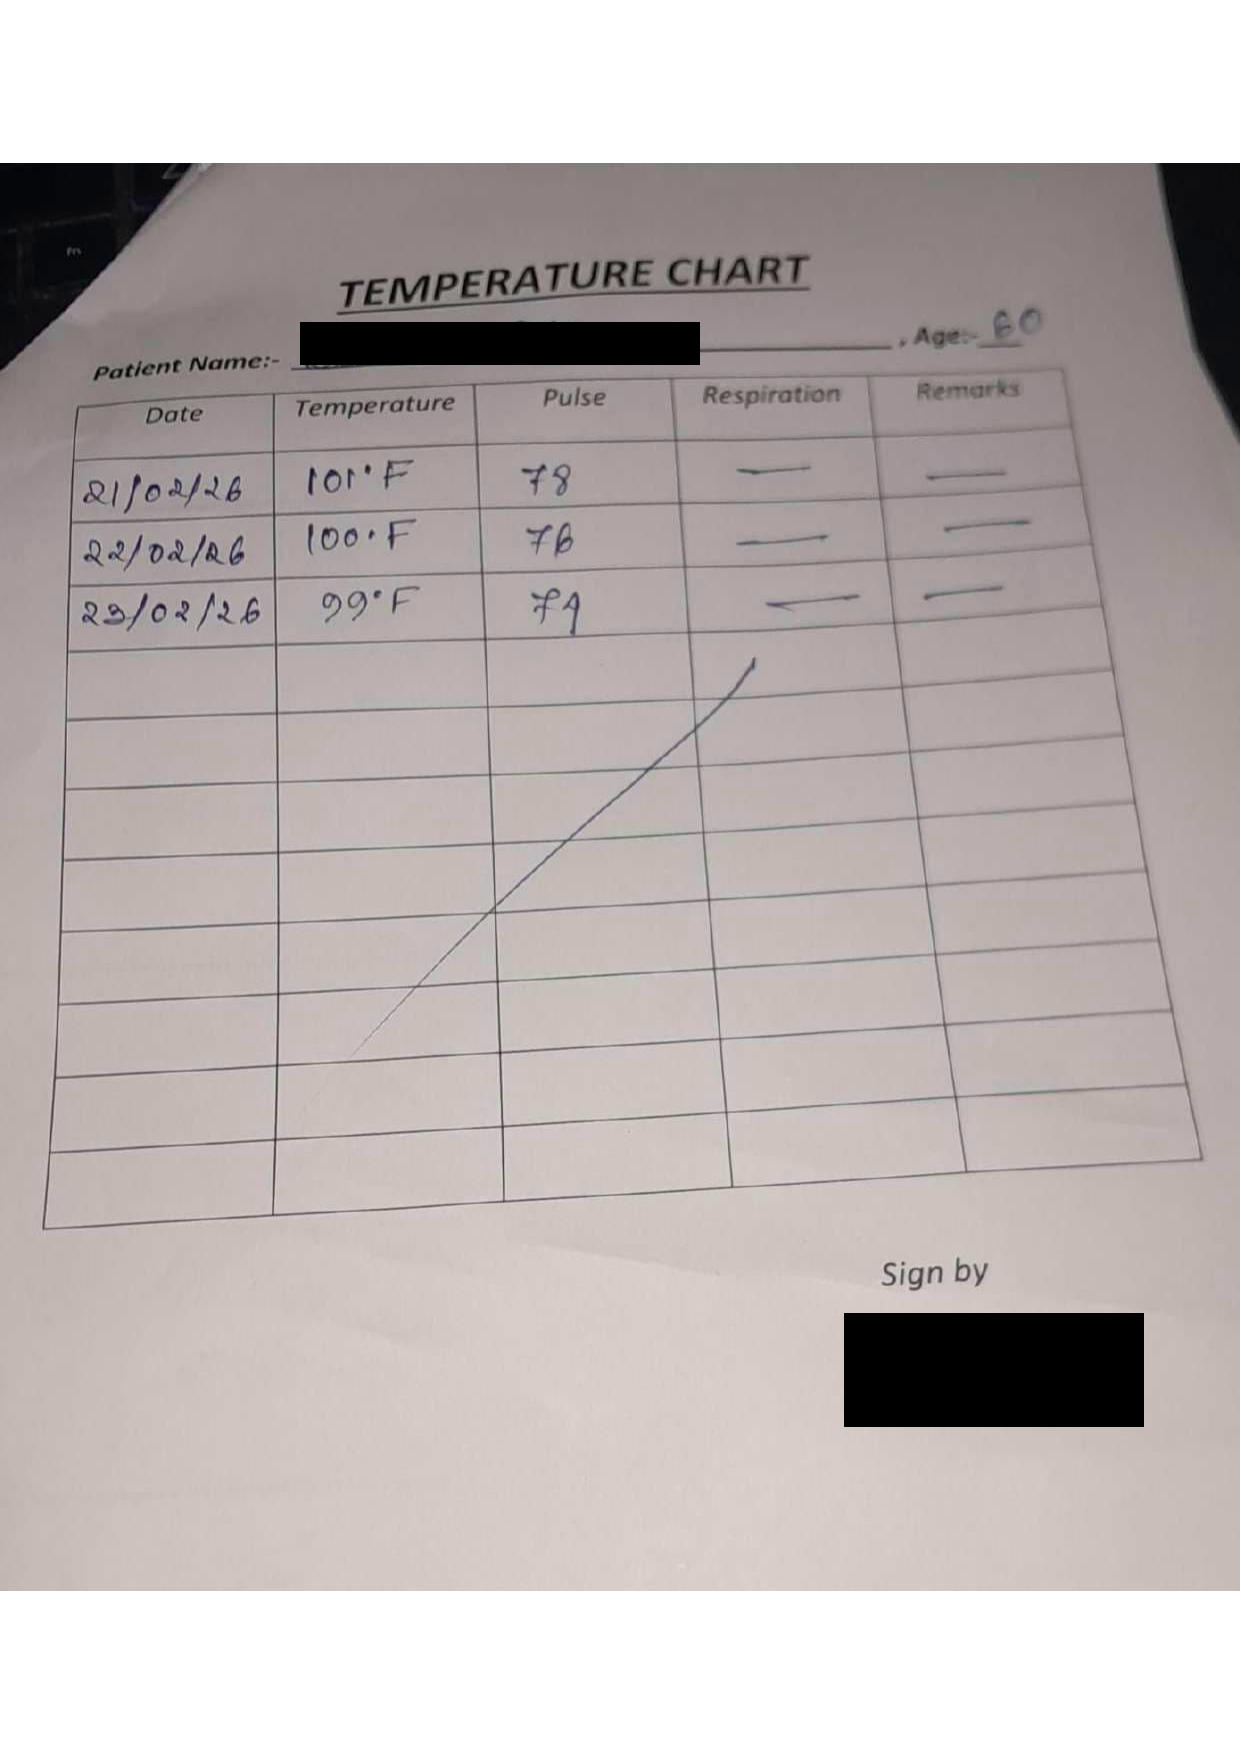

In [18]:
all_pages[1]["image"]

## Run OCR on Sample Page
Calls `run_ocr` on the selected page and stores the results in `full_text` (the merged text string) and `ocr_lines` (structured `OCRLine` objects).

In [19]:
full_text, ocr_lines = run_ocr(page_image = all_pages[1]["image"])

2026-04-24 10:46:02,096 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


## Inspect Extracted Text
Prints the raw text extracted from the sample page — useful for checking OCR quality and completeness.

In [20]:
full_text

'TEMPERATURE CHART\nPatient Name:-\nAge- 60\nDate Temperature Pulse Respiration Remarks\n21/02/26 101°F 78 \n22/02/26 100°F 78\n23/02/26 99°F 79\nSign by'

## Inspect OCR Lines
Prints the list of `OCRLine` objects, each carrying the text span, bounding-box coordinates, and confidence score from PaddleOCR.

In [21]:
ocr_lines

[OCRLine(text='TEMPERATURE CHART', bbox=[317, 100, 907, 170], confidence=0.9997052550315857),
 OCRLine(text='Patient Name:-', bbox=[0, 192, 256, 248], confidence=0.998026430606842),
 OCRLine(text='.Age6O', bbox=[1006, 168, 1210, 243], confidence=0.737278163433075),
 OCRLine(text='Date', bbox=[72, 260, 165, 310], confidence=0.9994635581970215),
 OCRLine(text='Pulse', bbox=[559, 260, 657, 306], confidence=0.999025821685791),
 OCRLine(text='Respiration', bbox=[759, 258, 947, 308], confidence=0.9815127849578857),
 OCRLine(text='Remarks', bbox=[1028, 256, 1178, 311], confidence=0.9986587166786194),
 OCRLine(text='Temperature', bbox=[263, 267, 470, 312], confidence=0.9999390244483948),
 OCRLine(text='21/02/26', bbox=[0, 347, 213, 425], confidence=0.9377161264419556),
 OCRLine(text="101'F", bbox=[265, 345, 421, 415], confidence=0.8571159243583679),
 OCRLine(text='78', bbox=[527, 356, 613, 424], confidence=0.9974064826965332),
 OCRLine(text='22/02/R6', bbox=[5, 429, 215, 500], confidence=0.888

# 4. LAYOUT / DOCUMENT TYPE CLASSIFIER

## Page Quality Estimator
`estimate_page_quality` evaluates whether a page is usable by measuring sharpness (Laplacian variance), text density, and low-text flags. Sets `poor_quality = 1` only when the page is both blurry and has very little text (e.g. a plain X-ray image).

In [23]:
import cv2
import numpy as np
from typing import Any, Dict

# =========================
# PATCH-BASED BLUR SCORING
# =========================
def compute_patch_blur(gray, patch_size=64):
    h, w = gray.shape
    scores = []

    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = gray[y:y+patch_size, x:x+patch_size]

            if patch.shape[0] < 32 or patch.shape[1] < 32:
                continue

            score = cv2.Laplacian(patch, cv2.CV_64F).var()
            scores.append(score)

    if len(scores) == 0:
        return 0.0, 0.0

    mean_score = float(np.mean(scores))
    worst_score = float(np.percentile(scores, 20))  # critical region

    return mean_score, worst_score


# =========================
# MAIN QUALITY ESTIMATOR
# =========================
def estimate_page_quality(page_image: Any) -> Dict[str, Any]:

    img_np = pil_to_numpy(page_image)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    h, w = gray.shape
    area = h * w

    # =========================================================
    # PREPROCESS (stabilize signals)
    # =========================================================
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # =========================================================
    # 1. IMPROVED BLUR DETECTION (PATCH-BASED)
    # =========================================================
    patch_mean, patch_worst = compute_patch_blur(gray)

    # Global fallback (still useful)
    global_lap = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    # Final blur decision (KEY FIX)
    is_blurry = (
        patch_worst < 45 or        # worst region is blurry
        patch_mean < 60 or         # overall softness
        global_lap < 50            # fallback global check
    )

    # =========================================================
    # 2. BRIGHTNESS & CONTRAST
    # =========================================================
    brightness = float(np.mean(gray))
    contrast = float(np.std(gray))

    too_dark = brightness < 80
    too_bright = brightness > 200
    low_contrast = contrast < 30

    # =========================================================
    # 3. NOISE ESTIMATION
    # =========================================================
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    noise = float(np.std(gray - blurred))
    is_noisy = noise > 25

    # =========================================================
    # 4. EDGE DENSITY
    # =========================================================
    edges = cv2.Canny(gray, 50, 150)
    edge_density = float(np.sum(edges > 0) / area)

    # =========================================================
    # 5. LINE DETECTION
    # =========================================================
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=w * 0.3,
        maxLineGap=10
    )

    line_count = 0 if lines is None else len(lines)

    # =========================================================
    # 6. SKEW DETECTION
    # =========================================================
    skew_angle = 0.0
    if lines is not None:
        angles = []
        for line in lines[:50]:
            x1, y1, x2, y2 = line[0]
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            angles.append(angle)

        if angles:
            skew_angle = float(np.median(angles))

    is_skewed = abs(skew_angle) > 5

    # =========================================================
    # 7. LAYOUT COMPLEXITY
    # =========================================================
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_count = len(contours)
    contour_density = contour_count / 1000.0

    # =========================================================
    # 8. WHITE SPACE
    # =========================================================
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    white_ratio = float(np.sum(thresh == 255) / area)

    # =========================================================
    # 9. FINAL QUALITY FLAG (IMPROVED LOGIC)
    # =========================================================
    poor_quality = 1 if (
        is_blurry or
        low_contrast or
        too_dark or
        is_noisy or
        is_skewed
    ) else 0

    return {
        # ---------------- BLUR (NEW SYSTEM) ----------------
        "patch_blur_mean": patch_mean,
        "patch_blur_worst": patch_worst,
        "global_laplacian": global_lap,

        "is_blurry": is_blurry,

        # ---------------- LIGHTING ----------------
        "brightness": brightness,
        "contrast": contrast,
        "too_dark": too_dark,
        "too_bright": too_bright,
        "low_contrast": low_contrast,

        # ---------------- NOISE ----------------
        "noise": noise,
        "is_noisy": is_noisy,

        # ---------------- STRUCTURE ----------------
        "edge_density": edge_density,
        "line_count": line_count,

        # ---------------- GEOMETRY ----------------
        "skew_angle": skew_angle,
        "is_skewed": is_skewed,

        # ---------------- LAYOUT ----------------
        "contour_count": contour_count,
        "contour_density": contour_density,

        # ---------------- COMPOSITION ----------------
        "white_ratio": white_ratio,

        # ---------------- FINAL ----------------
        "poor_quality": poor_quality,
    }

## Quality Check on Sample Page
Runs `estimate_page_quality` on the first page and prints the quality metrics dictionary.

In [81]:
# Test quality check
target_page_number = 29

for i, page in enumerate(all_pages):
    if page["page_number"] == target_page_number:
        result = estimate_page_quality(page["image"])

        print("\n========================")
        print(f"Index        : {i}")
        print(f"File name    : {page['file_name']}")
        print(f"Page number  : {page['page_number']}")
        print("========================")

        print(result)
        break


Index        : 54
File name    : 000845__CMJAY_TR_CMJAY_2025_R3_2026031110037177__babyofjesminadarlongdocument_11zon.pdf
Page number  : 29
{'patch_blur_mean': 161.2529016099943, 'patch_blur_worst': 0.0, 'global_laplacian': 132.11058825367022, 'is_blurry': True, 'brightness': 217.319397954899, 'contrast': 76.85086861931862, 'too_dark': False, 'too_bright': True, 'low_contrast': False, 'noise': 83.69259788602398, 'is_noisy': True, 'edge_density': 0.04395892156709609, 'line_count': 8, 'skew_angle': -90.0, 'is_skewed': True, 'contour_count': 1029, 'contour_density': 1.029, 'white_ratio': 0.7417046979989103, 'poor_quality': 1}


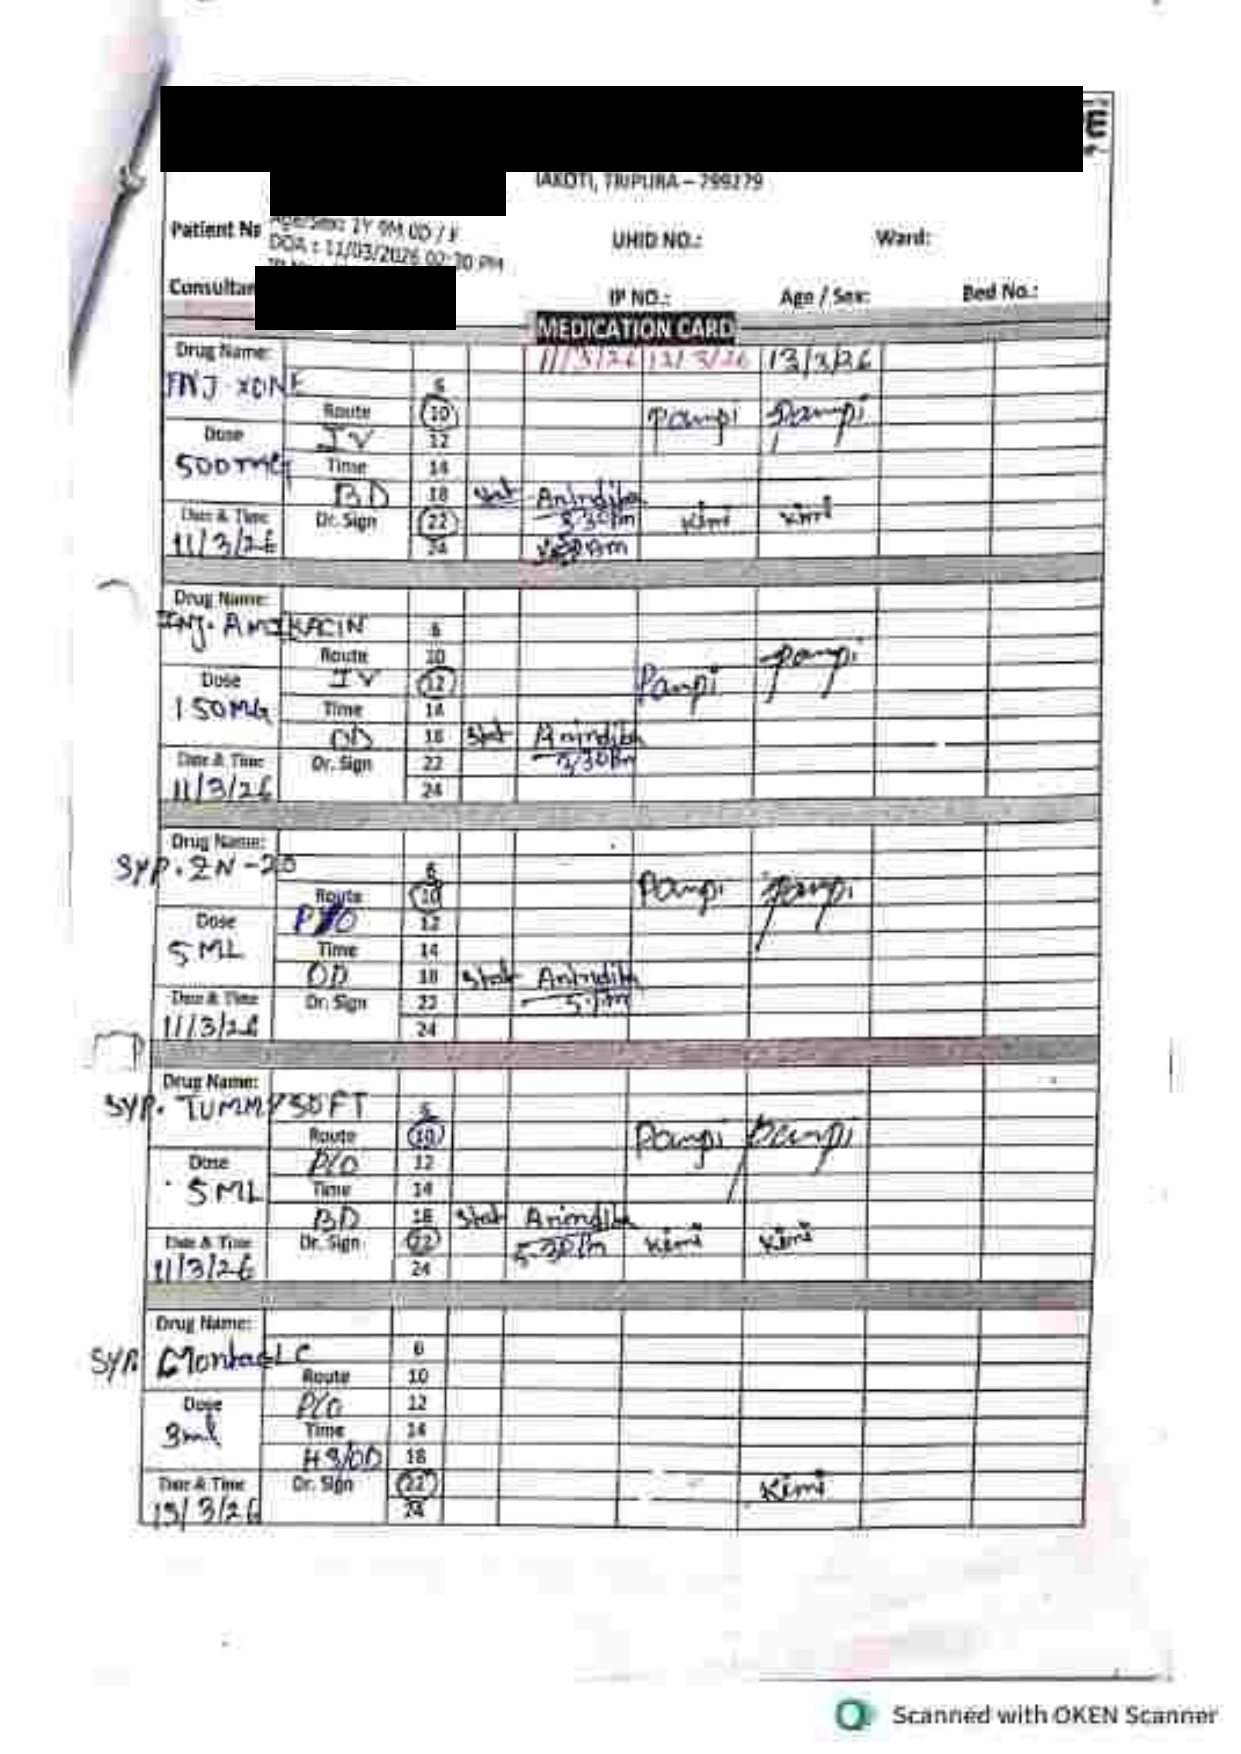

In [ ]:
all_pages[28]["image"]

# 5. VISUAL CUE DETECTION


## Visual Element Detector
`detect_visual_elements` sends the page image to the VLM with a structured JSON prompt asking it to flag the presence of photographs, X-rays, stamps, signatures, barcodes, implant stickers, and more. Falls back to all-zero defaults on any API or parsing error.

In [25]:
def safe_parse_json(content: str) -> Dict[str, Any]:
    import re, json

    try:
        # remove markdown blocks
        content = re.sub(r"```json", "", content)
        content = re.sub(r"```", "", content).strip()

        return json.loads(content)
    except:
        pass

    # fallback recovery for broken JSON
    try:
        json_match = re.search(r"\{.*", content, re.DOTALL)
        if json_match:
            partial = json_match.group()

            # fix broken quotes
            if partial.count('"') % 2 != 0:
                partial += '"'

            # fix missing braces
            open_braces = partial.count("{")
            close_braces = partial.count("}")
            partial += "}" * (open_braces - close_braces)

            return json.loads(partial)

    except Exception as e:
        print("⚠️ JSON recovery failed:", e)

    return {}

In [ ]:
# =========================
# 5. VISUAL CUE DETECTION
# =========================

visual_cache = {}

def detect_visual_elements(
    page_image: Any,
    case_id: Optional[str] = None,
    file_name: Optional[str] = None,
    page_number: Optional[int] = None
) -> Dict[str, Any]:

    default_output = {
        "has_signature": False,
        "has_stamp": False,
        "has_qr": False,
        "has_barcode": False,
        "has_implant_sticker": False,
        "has_medical_photo": False,
        "document_type_hint": "unknown",
        "confidence": 0.0,
        "evidence": {},
        "source": {
            "case_id": case_id,
            "file_name": file_name,
            "page_number": page_number
        }
    }

    try:
        print(f"\n🔍 [Visual] Processing: {file_name} | Page {page_number}")

        # =========================
        # CACHE
        # =========================
        cache_key = f"{case_id}_{file_name}_{page_number}"
        if cache_key in visual_cache:
            print("⚡ Using cached result")
            return visual_cache[cache_key]

        # =========================
        # IMAGE → BASE64
        # =========================
        buffer = io.BytesIO()
        page_image.save(buffer, format="PNG")
        image_b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
        data_url = f"data:image/png;base64,{image_b64}"

        # =========================
        # PROMPT
        # =========================
        prompt = """
Detect visual elements in this medical document.

Return ONLY JSON:
{
  "has_signature": true/false,
  "has_stamp": true/false,
  "has_qr": true/false,
  "has_barcode": true/false,
  "has_implant_sticker": true/false,
  "has_medical_photo": true/false,
  "document_type_hint": "...",
  "confidence": 0-1,
  "evidence": {
    "signature": "...",
    "stamp": "...",
    "document_type_reason": "..."
  }
}
"""

        # =========================
        # API CALL
        # =========================
        response = client.completion(
            model="Gemma 3 4B",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "image_url", "image_url": {"url": data_url}},
                        {"type": "text", "text": prompt}
                    ]
                }
            ],
            metadata={"problem_statement": 1}
        )

        print("📦 Response received")

        # =========================
        # RESPONSE EXTRACTION
        # =========================
        content = ""

        if isinstance(response, dict):
            if "choices" in response:
                content = response["choices"][0]["message"]["content"]
            elif "result" in response:
                content = response["result"]
            elif "output" in response:
                content = response["output"]
            else:
                print("⚠️ Unknown response format:", response)
                return default_output

        if not content.strip():
            print("⚠️ Empty content")
            return default_output

        print("🧠 Raw content:", content[:300])

        # =========================
        # 🔥 FIXED JSON PARSING
        # =========================
        parsed = safe_parse_json(content)

        if not parsed:
            print("⚠️ Could not parse JSON, using defaults")
            return default_output

        # =========================
        # CLEAN OUTPUT
        # =========================
        cleaned = default_output.copy()

        for key in [
            "has_signature",
            "has_stamp",
            "has_qr",
            "has_barcode",
            "has_implant_sticker",
            "has_medical_photo",
            "document_type_hint",
            "confidence"
        ]:
            if key in parsed:
                cleaned[key] = parsed[key]

        if "evidence" in parsed and isinstance(parsed["evidence"], dict):
            cleaned["evidence"] = parsed["evidence"]

        # =========================
        # TYPE SAFETY
        # =========================
        cleaned["confidence"] = float(cleaned.get("confidence", 0.0))

        for k in [
            "has_signature",
            "has_stamp",
            "has_qr",
            "has_barcode",
            "has_implant_sticker",
            "has_medical_photo"
        ]:
            cleaned[k] = bool(cleaned.get(k, False))

        # =========================
        # CACHE SAVE
        # =========================
        visual_cache[cache_key] = cleaned

        print("✅ Detection success:", cleaned)

        return cleaned

    except Exception as e:
        print(f"❌ Detection failed: {e}")
        return default_output

## Test Visual Detection
Runs `detect_visual_elements` on the sample page and prints each detected tag and its value.

In [85]:
page_idx = 28

if len(all_pages) > page_idx:
    p = all_pages[page_idx]

    visual_tags = detect_visual_elements(
        p["image"],
        case_id=CASE_ID[0],
        file_name=p["file_name"],
        page_number=page_idx + 1
    )

    print(visual_tags)


🔍 [Visual] Processing: 000845__CMJAY_TR_CMJAY_2025_R3_2026031110037177__babyofjesminadarlongdocument_11zon.pdf | Page 29
⚡ Using cached result
{'has_signature': True, 'has_stamp': True, 'has_qr': False, 'has_barcode': True, 'has_implant_sticker': False, 'has_medical_photo': False, 'document_type_hint': 'Discharge Summary', 'confidence': 0.95, 'evidence': {'signature': 'Signature in the language best known to the patient', 'stamp': 'Top right corner - appears to be a medical facility stamp', 'document_type_reason': "Title 'DISCHARGE SUMMARY' and common discharge summary layout detected."}, 'source': {'case_id': 'MG006A', 'file_name': '000845__CMJAY_TR_CMJAY_2025_R3_2026031110037177__babyofjesminadarlongdocument_11zon.pdf', 'page_number': 29}}


## Visual Tag → Field Mapping
`VISUAL_TAG_TO_FIELD` maps visual detection results to their corresponding output schema field names, on a per-package basis (e.g. `is_xray_knee` → `xray_ct_knee` for `SB039A`).

In [86]:
# You'll use this inside populate_row_for_package later

VISUAL_TAG_TO_FIELD = {
    "SG039C": {
        "is_intraop_photo": "photo_evidence",      # intraoperative photo
    },
    "SB039A": {
        "is_post_op_photo":        "post_op_photo",         # post-op clinical photo
        "is_xray_knee":            "xray_ct_knee",          # pre-op knee X-ray
        "implant_visible_in_xray": "post_op_implant_present", # implant in post-op xray
        "has_implant_sticker":     "implant_invoice",       # barcode/invoice sticker
        "has_barcode_qr":          "implant_invoice",       # QR on invoice page
    }
}

## Display Sample Page (Visual Check)
Re-renders the sample page image so the visual detection results above can be cross-checked against what is actually on the page.

In [ ]:
all_pages[28]["image"]


# 6. ENTITY EXTRACTION


## Fallback Document Type List
Defines `DOCUMENT_TYPES`, a flat list of all possible document type labels used as a fallback when a package-specific list is unavailable.

In [87]:
# Fallback Mechanicsm
DOCUMENT_TYPES = [
    "clinical_notes",
    "cbc_hb_report",
    "indoor_case",
    "treatment_details",
    "post_hb_report",
    "discharge_summary",
    "usg_report",
    "lft_report",
    "operative_notes",
    "pre_anesthesia",
    "histopathology",
    "xray_ct_knee",
    "investigation_pre",
    "investigation_post",
    "vitals_treatment",
    "implant_invoice",
    "post_op_photo",
    "post_op_xray",
    "photo_evidence",
    "extra_document",
]

## Document Type Classifier
`classify_document_type` builds a prompt combining OCR text and visual cue summaries, then asks the VLM (Gemma 3 4B) to assign one document-type label from the package-specific allowed list. The result is validated against the allowed list; unrecognised types fall back to `extra_document`.

In [88]:
# =========================
# 6. ENTITY EXTRACTION
# =========================

# Package-specific document type lists — only show relevant types per package
PACKAGE_DOC_TYPES = {
    "MG064A": ["clinical_notes", "cbc_hb_report", "indoor_case",
               "treatment_details", "post_hb_report", "discharge_summary",
               "extra_document"],
    "SG039C": ["clinical_notes", "usg_report", "lft_report", "operative_notes",
               "pre_anesthesia", "discharge_summary", "photo_evidence",
               "histopathology", "extra_document"],
    "MG006A": ["clinical_notes", "investigation_pre", "vitals_treatment",
               "investigation_post", "discharge_summary", "extra_document"],
    "SB039A": ["clinical_notes", "xray_ct_knee", "indoor_case", "operative_notes",
               "implant_invoice", "post_op_photo", "post_op_xray",
               "discharge_summary", "extra_document"],
}

def classify_document_type(
    package_code: str,
    extracted_text: str,
    visual_tags: Dict[str, Any],
    page_image: Any = None,
) -> Dict[str, Any]:

    valid_types = PACKAGE_DOC_TYPES.get(package_code, DOCUMENT_TYPES)

    visual_summary = ", ".join(
    k for k, v in visual_tags.items()
    if k != "reason" and v == 1
    ) or "none detected"

    prompt = f"""You are analyzing a PM-JAY Indian health insurance claim document page.
Package: {package_code}

OCR Text extracted from this page:
\"\"\"
{extracted_text[:1500]}
\"\"\"



# Then in the prompt f-string add:
f"\nVisual cues detected on this page: {visual_summary}\n"

Classify this page into EXACTLY ONE of these document types:
{json.dumps(valid_types, indent=2)}

Definitions:
- clinical_notes: doctor's written notes, outpatient slip, case history, presenting complaints
- cbc_hb_report: CBC or hemoglobin lab investigation report (pre-treatment)
- indoor_case: indoor case paper, admission record, IPD registration
- treatment_details: treatment/transfusion chart, medication administration record
- post_hb_report: CBC/Hb lab report AFTER treatment
- discharge_summary: formal discharge summary document
- investigation_pre: any lab/diagnostic report BEFORE treatment (blood, urine, culture, Widal etc.)
- investigation_post: any lab/diagnostic report AFTER treatment
- vitals_treatment: temperature chart, vitals monitoring sheet, nursing notes
- usg_report: ultrasound report
- lft_report: liver function test report
- operative_notes: operation notes, surgical procedure record
- pre_anesthesia: pre-anaesthesia check-up form
- photo_evidence: photograph of patient, wound, or surgical site
- histopathology: biopsy or histopathology report
- xray_ct_knee: X-ray or CT scan of knee joint
- implant_invoice: invoice/bill for implant or prosthesis
- post_op_photo: post-operative photograph
- post_op_xray: post-operative X-ray
- extra_document: consent forms, identity cards, unrelated prescriptions, anything NOT in the above list

Respond in JSON only:
{{
  "doc_type": "<one of the valid types above>",
  "confidence": <float 0.0 to 1.0>,
  "reason": "<one sentence explaining why>"
}}"""

    try:
        # Send image + text to VLM for best accuracy
        messages_content = []
        if page_image is not None:
            image_b64 = pil_to_base64(page_image)
            data_url  = f"data:image/png;base64,{image_b64}"
            messages_content.append({"type": "image_url", "image_url": {"url": data_url}})
        messages_content.append({"type": "text", "text": prompt})

        response = client.completion(
            model="Gemma 3 4B",
            messages=[{"role": "user", "content": messages_content}],
            metadata={"problem_statement": 1}
        )

        raw = response["choices"][0]["message"]["content"].strip()

        # Strip markdown code fences if present
        raw = re.sub(r"^```(?:json)?\s*", "", raw)
        raw = re.sub(r"\s*```$", "", raw)

        result = json.loads(raw)

        doc_type   = result.get("doc_type", "extra_document")
        confidence = float(result.get("confidence", 0.0))
        reason     = result.get("reason", "")

        # Validate — reject if not in valid list
        if doc_type not in valid_types:
            doc_type   = "extra_document"
            confidence = 0.0
            reason     = f"Model returned unknown type, defaulted to extra_document"

        return {
            "doc_type":   doc_type,
            "confidence": confidence,
            "reason":     reason,
        }

    except Exception as e:
        print(f"[WARN] classify_document_type failed: {e}")
        return {"doc_type": "extra_document", "confidence": 0.0, "reason": str(e)}

## Test Document Classification
Runs `classify_document_type` on the sample page using `MG006A`'s allowed types and prints the predicted `doc_type`, confidence score, and reasoning.

In [89]:
# Test classification with visual tags 
doc_result = classify_document_type(
    package_code   = "MG006A",
    extracted_text = full_text,        # from your run_ocr earlier
    visual_tags    = visual_tags,      # from Cell 1
    page_image     = all_pages[28]["image"]
)

print("=== CLASSIFICATION ===")
print(f"  doc_type  : {doc_result['doc_type']}")
print(f"  confidence: {doc_result['confidence']}")
print(f"  reason    : {doc_result['reason']}")

2026-04-24 11:34:27,930 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


=== CLASSIFICATION ===
  doc_type  : vitals_treatment
  confidence: 0.95
  reason    : The page contains a temperature chart with patient details, indicating it's a record of vital signs monitoring, which falls under the category of vitals_treatment.


## Entity Extraction Utilities
Provides three regex-based helpers:
- `find_dates` — extracts date strings in multiple Indian formats.
- `find_age` — finds patient age from common phrasings ("Age: 60", "60 yrs", etc.).
- `contains_any` — returns `1` if any keyword from a list appears in the text (used for binary clinical-condition flags).

In [45]:
# =========================
# ENTITY EXTRACTION HELPERS
# =========================

#TODO - Can Agents / LLM Dynamically Create Patterns to Extract Dates, Age and Contains ?
DATE_PATTERNS = [
    r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
    r"\b\d{1,2}-[A-Za-z]{3}-\d{2,4}\b",
    r"\b\d{1,2}\s+[A-Za-z]{3,9}\s+\d{2,4}\b",
    r"[Aa]ge[\s\W]*(\d{1,3})"  
]

def find_dates(text: str) -> List[str]:
    seen = []
    for pattern in DATE_PATTERNS:
        for match in re.finditer(pattern, text, re.IGNORECASE):
            val = match.group().strip()
            if val not in seen:
                seen.append(val)
    return seen


def find_age(text: str) -> Optional[int]:
    # Matches: "Age: 60", "60 years", "60 yrs", "60Y", "Age/60"
    patterns = [
        r"\bage[:\s/]*(\d{1,3})\s*(?:years?|yrs?|y\b)?",
        r"\b(\d{1,3})\s*(?:years?|yrs?)\s*(?:old)?",
        r"\b(\d{1,3})\s*[Yy]\b",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            age = int(match.group(1))
            if 1 <= age <= 120:   # sanity check
                return age
    return None


def contains_any(text: str, keywords: List[str]) -> int:
    text_lower = text.lower()
    for kw in keywords:
        if kw.lower() in text_lower:
            return 1
    return 0

## Clinical Keyword Lists
Defines keyword sets for each package's clinical condition fields, derived from the Standard Treatment Guidelines (STG): anaemia signs for `MG064A`, fever/enteric symptoms for `MG006A`, arthritis indicators for `SB039A`, and cholecystitis/calculi terms for `SG039C`.

In [46]:
# Keywords for clinical condition fields — derived from STG documents

# MG064A — Severe Anemia (STG Section 1.2)
KW_SEVERE_ANEMIA    = ["hb", "hemoglobin", "haemoglobin", "7 g", "6 g", "5 g",
                        "severe anemia", "severe anaemia", "<7", "< 7"]
KW_COMMON_SIGNS     = ["pallor", "fatigue", "weakness", "tiredness", "pale",
                        "lethargy", "dyspnea on exertion"]
KW_SIGNIFICANT_SIGNS= ["tachycardia", "breathlessness", "palpitation",
                        "rapid pulse", "dyspnea", "pedal edema"]
KW_LIFE_THREATENING = ["cardiac failure", "heart failure", "severe hypoxia",
                        "shock", "altered sensorium", "unconscious", "collapse"]

# MG006A — Enteric Fever (STG Section 1.2 + 3.2.1)
KW_FEVER            = ["fever", "38.3", "101", "pyrexia", "febrile",
                        "high temperature", "hyperthermia"]
KW_SYMPTOMS_FEVER   = ["headache", "dizziness", "myalgia", "weakness",
                        "malaise", "pain in muscles", "pain in joints"]

# SB039A — Total Knee Replacement (STG Section 1.2)
KW_ARTHRITIS        = ["osteoarthritis", "rheumatoid", "osteonecrosis",
                        "inflammatory arthritis", "genu varum", "knee pain",
                        "joint instability", "locking", "post trauma"]

# SG039C — Cholecystectomy (STG Section 1.2)
KW_CLINICAL_COND    = ["biliary colic", "cholecystitis", "pancreatitis",
                        "choledocholithiasis", "cholangitis", "gall stone",
                        "gallstone", "right hypochondrium", "epigastrium"]
KW_USG_CALCULI      = ["calculi", "stone", "cholelithiasis", "gallstone",
                        "gall stone", "usg"]
KW_PAIN             = ["pain", "right hypochondrium", "epigastric", "epigastrium"]
KW_PREV_SURGERY     = ["previous cholecystectomy", "prior surgery",
                        "revision", "past surgery"]

## Test Entity Extraction
Runs all three helpers on `full_text` and prints the extracted dates, patient age, and whether fever/symptom keywords are present — verifies the regex patterns work against real OCR output.

In [47]:
# Testing Entity Extraction Helper on Full Text

print("=== Real OCR text extraction ===")
print(f"Dates found  : {find_dates(full_text)}")
print(f"Age found    : {find_age(full_text)}")
print(f"Fever present: {contains_any(full_text, KW_FEVER)}")
print(f"Symptoms     : {contains_any(full_text, KW_SYMPTOMS_FEVER)}")

=== Real OCR text extraction ===
Dates found  : ['21/02/26', '22/02/26', '23/02/26', 'Age- 60']
Age found    : None
Fever present: 1
Symptoms     : 0


# 7. PAGE-TO-ROW MAPPING

## Output Row Initialiser
`initialize_output_row` creates a blank output dict for a given package and page, pre-filled with metadata (`case_id`, `link`, `procedure_code`, `page_number`) and zeros for all binary fields. `normalize_output_key` resolves S3-link key aliases before writing.

In [48]:
# =========================
# PACKAGE ROW INITIALIZERS
# =========================

def normalize_output_key(key: str) -> str:
    return KEY_ALIASES.get(key, key)

def initialize_output_row(
    package_code: str,
    case_id: str,
    file_name: str,
    page_number: int
) -> Dict[str, Any]:

    schema = PACKAGE_SCHEMAS[package_code]
    row    = {}

    for key in schema:
        nkey = normalize_output_key(key)

        if key == "case_id":
            row[nkey] = case_id

        elif key in ("link", "S3_link", "S3_link/DocumentName", "s3_link"):
            row[nkey] = file_name

        elif key == "procedure_code":
            row[nkey] = package_code

        elif key == "page_number":
            row[nkey] = page_number

        elif key in ("pre_date", "post_date", "doa", "dod"):
            row[nkey] = None          # nullable date fields

        else:
            row[nkey] = 0             # all binary fields default to 0

    return row

## Date Normaliser
`normalize_date` tries a list of common Indian date formats and returns a standardised `DD-MM-YYYY` string. If no format matches, the raw input string is returned unchanged.

In [49]:
# =========================
# DATE NORMALIZATION UTIL
# =========================

from datetime import datetime

def normalize_date(date_str: Optional[str]) -> Optional[str]:
    if not date_str:
        return None

    candidates = [
        "%d/%m/%y", "%d/%m/%Y",
        "%d-%m-%y", "%d-%m-%Y",
        "%d-%b-%y", "%d-%b-%Y",
        "%d %b %Y", "%d %B %Y",
        "%m/%d/%y", "%m/%d/%Y",  # keep only if your data needs it
    ]

    for fmt in candidates:
        try:
            dt = datetime.strptime(date_str, fmt)
            return dt.strftime("%d-%m-%Y")
        except Exception:
            continue
    return date_str

In [50]:
# =========================
# DOCUMENT RANKING
# =========================

RANK_MAP = {
    "MG064A": {
        "clinical_notes": 1,
        "cbc_hb_report": 2,
        "indoor_case": 2,
        "treatment_details": 3,
        "post_hb_report": 4,
        "discharge_summary": 5,
    },
    "SG039C": {
        "clinical_notes": 1,
        "usg_report": 2,
        "lft_report": 3,
        "pre_anesthesia": 4,
        "operative_notes": 5,
        "discharge_summary": 5,
        "histopathology": 6,
        "photo_evidence": 6,
    },
    "MG006A": {
        "clinical_notes": 1,
        "investigation_pre": 2,
        "vitals_treatment": 3,
        "investigation_post": 4,
        "discharge_summary": 5,
    },
    "SB039A": {
        "clinical_notes": 1,
        "xray_ct_knee": 2,
        "indoor_case": 3,
        "operative_notes": 4,
        "implant_invoice": 5,
        "post_op_photo": 6,
        "post_op_xray": 6,
        "discharge_summary": 7,
    }
}

def infer_document_rank(package_code: str, row: Dict[str, Any], doc_type: str) -> Optional[int]:
    '''
    Determine the page/document position in the expected clinical timeline.

    Expected behavior when implemented:
    - assign the package-specific rank based on document type and context
    - return rank 99 for extra documents
    - keep the same rank across all pages belonging to the same logical document where required
    '''
    # Extra documents always get rank 99
    if row.get("extra_document", 0) == 1:
        return 99

    # Look up rank from RANK_MAP
    pkg_ranks = RANK_MAP.get(package_code, {})
    rank      = pkg_ranks.get(doc_type, None)

    # Unknown doc type that isn't marked extra → still 99
    if rank is None:
        return 99

    return rank


In [51]:
# Test infer_document_rank
tests = [
    ("MG006A", {"extra_document": 0}, "discharge_summary"),   # → 5
    ("MG006A", {"extra_document": 0}, "investigation_pre"),    # → 2
    ("MG006A", {"extra_document": 1}, "discharge_summary"),    # → 99 (marked extra)
    ("SB039A", {"extra_document": 0}, "xray_ct_knee"),         # → 2
    ("SB039A", {"extra_document": 0}, "post_op_photo"),        # → 6
    ("MG064A", {"extra_document": 0}, "consent_form"),         # → 99 (unknown type)
]

for pkg, row, dt in tests:
    rank = infer_document_rank(pkg, row, dt)
    print(f"{pkg} | {dt:25s} | extra={row['extra_document']} → rank {rank}")

MG006A | discharge_summary         | extra=0 → rank 5
MG006A | investigation_pre         | extra=0 → rank 2
MG006A | discharge_summary         | extra=1 → rank 99
SB039A | xray_ct_knee              | extra=0 → rank 2
SB039A | post_op_photo             | extra=0 → rank 6
MG064A | consent_form              | extra=0 → rank 99


In [52]:
MANDATORY_DOCS = {
    "MG064A": ["clinical_notes", "cbc_hb_report", "indoor_case", "treatment_details", "post_hb_report", "discharge_summary"],
    "SG039C": ["clinical_notes", "usg_report", "lft_report", "operative_notes", "pre_anesthesia", "discharge_summary", "photo_evidence", "histopathology"],
    "MG006A": ["clinical_notes", "investigation_pre", "vitals_treatment", "investigation_post", "discharge_summary"],
    "SB039A": ["clinical_notes", "xray_ct_knee", "indoor_case", "operative_notes", "implant_invoice", "post_op_photo", "post_op_xray", "discharge_summary"],
}

In [90]:
page_idx = 0
page = all_pages[page_idx]

# Build PageResult
page_result = PageResult(
    case_id="000585__CMJAY_TR_CMJAY_2025_R3_1022010623",
    file_name=page["file_name"],
    page_number=page_idx + 1,
)

# OCR
page_result.extracted_text, page_result.ocr_lines = run_ocr(
    page_image=page["image"]
)

# Quality
page_result.quality = estimate_page_quality(
    page_image=page["image"]
)

2026-04-24 11:37:40,859 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


In [95]:
# Visual Detection
page_result.visual_tags = detect_visual_elements(page_image=all_pages[0]["image"])

# Classification
doc_out = classify_document_type(package_code="MG006A", extracted_text=page_result.extracted_text,
                                  visual_tags = page_result.visual_tags, page_image=all_pages[0]["image"])
page_result.doc_type            = doc_out["doc_type"]
page_result.doc_type_confidence = doc_out["confidence"]


🔍 [Visual] Processing: None | Page None
⚡ Using cached result


2026-04-24 11:48:38,857 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


In [96]:
def populate_row_for_package(
    package_code: str,
    page_result: PageResult,
) -> Dict[str, Any]:

    row = initialize_output_row(
        package_code = package_code,
        case_id      = page_result.case_id,
        file_name    = page_result.file_name,
        page_number  = page_result.page_number,
    )

    doc_type  = page_result.doc_type
    full_text = page_result.extracted_text
    text      = full_text.lower()
    vis       = page_result.visual_tags or {}    
    quality   = page_result.quality     or {}    

    # ── 2. doc_type presence ──────────────────────────────────────────────
    if doc_type in row:
        row[doc_type] = 1

    # ── 3. extra_document ─────────────────────────────────────────────────
    mandatory         = MANDATORY_DOCS.get(package_code, [])
    is_extra          = 0 if doc_type in mandatory else 1
    row["extra_document"] = is_extra              

    # ── 4. document_rank ──────────────────────────────────────────────────
    row["document_rank"] = infer_document_rank(package_code, row, doc_type)  

    # ── 5. Package-specific fields ────────────────────────────────────────
    if package_code == "MG064A":
        row["severe_anemia"]          = contains_any(text, KW_SEVERE_ANEMIA)
        row["common_signs"]           = contains_any(text, KW_COMMON_SIGNS)
        row["significant_signs"]      = contains_any(text, KW_SIGNIFICANT_SIGNS)
        row["life_threatening_signs"] = contains_any(text, KW_LIFE_THREATENING)

    elif package_code == "MG006A":
        row["poor_quality"] = quality.get("poor_quality", 0)
        row["fever"]        = contains_any(text, KW_FEVER)
        row["symptoms"]     = contains_any(text, KW_SYMPTOMS_FEVER)

        if doc_type == "investigation_pre":
            dates = find_dates(full_text)
            row["pre_date"]  = normalize_date(dates[0]) if dates else None
        elif doc_type == "investigation_post":
            dates = find_dates(full_text)
            row["post_date"] = normalize_date(dates[0]) if dates else None

    elif package_code == "SG039C":
        row["clinical_condition"] = contains_any(text, KW_CLINICAL_COND)
        row["usg_calculi"]        = contains_any(text, KW_USG_CALCULI)
        row["pain_present"]       = contains_any(text, KW_PAIN)
        row["previous_surgery"]   = contains_any(text, KW_PREV_SURGERY)

        if vis.get("is_intraop_photo") == 1:
            row["photo_evidence"] = 1

    elif package_code == "SB039A":
        row["arthritis_type"] = contains_any(text, KW_ARTHRITIS)

        if vis.get("is_xray_knee") == 1:
            row["xray_ct_knee"] = 1
        if vis.get("is_post_op_photo") == 1:
            row["post_op_photo"] = 1
        if vis.get("implant_visible_in_xray") == 1:
            row["post_op_xray"]            = 1
            row["post_op_implant_present"] = 1
        if vis.get("has_implant_sticker") == 1 or vis.get("has_barcode_qr") == 1:
            row["implant_invoice"] = 1

        if doc_type == "discharge_summary":
            dates    = find_dates(full_text)
            row["doa"] = normalize_date(dates[0]) if len(dates) > 0 else None
            row["dod"] = normalize_date(dates[1]) if len(dates) > 1 else None

        age = find_age(full_text)
        row["age_valid"] = 1 if (age is not None and age > 55) else 0

    # ── 6. Evidence for explainability ────────────────────────────────────
    page_result.evidence = {
        "doc_type"   : doc_type,
        "confidence" : page_result.doc_type_confidence,
        "is_extra"   : is_extra,
        "visual_hits": [k for k, v in vis.items() if k != "reason" and v == 1],
        "dates_found": find_dates(full_text),
        "age_found"  : find_age(full_text),
    }
    page_result.output_row = row
    return row

In [97]:
row = populate_row_for_package(package_code="MG006A", page_result=page_result)
print(json.dumps(row, indent=2, default=str))

{
  "case_id": "000585__CMJAY_TR_CMJAY_2025_R3_1022010623",
  "link": "000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf",
  "procedure_code": "MG006A",
  "page_number": 1,
  "clinical_notes": 1,
  "investigation_pre": 0,
  "pre_date": null,
  "vitals_treatment": 0,
  "investigation_post": 0,
  "post_date": null,
  "discharge_summary": 0,
  "poor_quality": 1,
  "fever": 1,
  "symptoms": 0,
  "extra_document": 0,
  "document_rank": 1
}


In [98]:
import pandas as pd
pd.DataFrame([row])

,case_id,link,procedure_code,page_number,clinical_notes,investigation_pre,pre_date,vitals_treatment,investigation_post,post_date,discharge_summary,poor_quality,fever,symptoms,extra_document,document_rank
0,000585__CMJAY_TR_CMJAY_2025_R3_1022010623,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,MG006A,1,1,0,None,0,0,None,0,1,1,0,0,1


In [99]:
# =========================
# 8. TIMELINE CONSTRUCTION
# =========================

def build_episode_timeline(
    package_code: str,
    page_results: List[PageResult]
) -> List[TimelineEvent]:

    timeline = []

    # ---------------------------
    # 1. DOC TYPE → EVENT TYPE MAP
    # ---------------------------
    DOC_TO_EVENT = {
     # Admission / initial assessment
    "clinical_notes":       "admission",
    "indoor_case":          "admission",

    # Pre-procedure investigations
    "cbc_hb_report":        "investigation",
    "usg_report":           "investigation",
    "lft_report":           "investigation",
    "investigation_pre":    "investigation",
    "investigation_post":   "investigation",
    "xray_ct_knee":         "investigation",

    # Procedure / treatment
    "pre_anesthesia":       "procedure",
    "operative_notes":      "procedure",
    "treatment_details":    "procedure",

    # Post-procedure monitoring
    "vitals_treatment":     "monitoring",
    "post_hb_report":       "monitoring",
    "post_op_photo":        "monitoring",
    "post_op_xray":         "monitoring",

    # Discharge
    "discharge_summary":    "discharge",

    # Supporting evidence
    "photo_evidence":       "evidence",
    "histopathology":       "evidence",
    "implant_invoice":      "evidence",
    }

    # ---------------------------
    # 2. EXTRACT EVENTS
    # ---------------------------
    for pr in page_results:

        doc_type = pr.doc_type
        text     = pr.extracted_text or ""

        event_type = DOC_TO_EVENT.get(doc_type, "other")

        # Extract date
        dates = find_dates(text)
        event_date = normalize_date(dates[0]) if dates else None

        event = TimelineEvent(
            sequence=0,  # will assign later
            event_type=event_type,
            date=event_date,
            source_document=f"{pr.file_name}|page_{pr.page_number}",
            temporal_validity="unknown",
            evidence={
                "doc_type": doc_type,
                "confidence": pr.doc_type_confidence,
                "document_rank": pr.output_row.get("document_rank") if pr.output_row else None
            }
        )

        timeline.append(event)

    # ---------------------------
    # 3. SORT TIMELINE
    # ---------------------------
    def sort_key(ev: TimelineEvent):
        # Prefer date → fallback to inferred order
        if ev.date:
            try:
                return (0, datetime.strptime(ev.date, "%d-%m-%Y"))
            except:
                pass
        return (1, ev.evidence.get("document_rank", 99))

    timeline.sort(key=sort_key)

    # ---------------------------
    # 4. ASSIGN SEQUENCE
    # ---------------------------
    for idx, ev in enumerate(timeline, start=1):
        ev.sequence = idx

    # ---------------------------
    # 5. TEMPORAL VALIDATION
    # ---------------------------
    seen_procedure = False

    for ev in timeline:

        if ev.event_type == "procedure":
            seen_procedure = True
            ev.temporal_validity = "valid"

        elif ev.event_type in ["investigation_pre", "admission"]:
            ev.temporal_validity = "before_procedure" if not seen_procedure else "invalid_after_procedure"

        elif ev.event_type in ["investigation_post", "monitoring", "post_procedure"]:
            ev.temporal_validity = "after_procedure" if seen_procedure else "invalid_before_procedure"

        elif ev.event_type == "discharge":
            ev.temporal_validity = "final"

        else:
            ev.temporal_validity = "unknown"

    return timeline

In [103]:
page_results = []

for idx, page in enumerate(all_pages):

    pr = PageResult(
        case_id="000585__CMJAY_TR_CMJAY_2025_R3_1022010623",
        file_name=page["file_name"],
        page_number=page["page_number"]
    )

    # OCR
    pr.extracted_text, pr.ocr_lines = run_ocr(page["image"])

    # Quality
    pr.quality = estimate_page_quality(page["image"])

    # Visual
    pr.visual_tags = detect_visual_elements(
        page["image"],
        case_id=pr.case_id,
        file_name=pr.file_name,
        page_number=pr.page_number
    )

    # Classification
    doc_out = classify_document_type(
        package_code="MG006A",
        extracted_text=pr.extracted_text,
        visual_tags=pr.visual_tags,
        page_image=page["image"]
    )

    pr.doc_type = doc_out["doc_type"]
    pr.doc_type_confidence = doc_out["confidence"]

    # Row mapping (IMPORTANT for timeline rank)
    populate_row_for_package("MG006A", pr)

    page_results.append(pr)

2026-04-24 11:59:26,555 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"



🔍 [Visual] Processing: 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf | Page 1


2026-04-24 11:59:28,631 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


📦 Response received
🧠 Raw content: ```json
{
  "has_signature": true,
  "has_stamp": true,
  "has_qr": false,
  "has_barcode": false,
  "has_implant_sticker": false,
  "has_medical_photo": false,
  "document_type_hint": "Medical Record/Progress Note",
  "confidence": 0.95,
  "evidence": {
    "signature": "A handwritten signature is 
✅ Detection success: {'has_signature': True, 'has_stamp': True, 'has_qr': False, 'has_barcode': False, 'has_implant_sticker': False, 'has_medical_photo': False, 'document_type_hint': 'Medical Record/Progress Note', 'confidence': 0.95, 'evidence': {'signature': 'A handwritten signature is visible in the bottom right corner.', 'stamp': 'A stamp is visible at the top left corner.'}, 'source': {'case_id': '000585__CMJAY_TR_CMJAY_2025_R3_1022010623', 'file_name': '000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf', 'page_number': 1}}


2026-04-24 11:59:30,323 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-24 12:01:14,616 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


...


🔍 [Visual] Processing: 000590__CMJAY_TR_CMJAY_2025_R3_1022010623__36acf382-6069-49c4-b705-a1c62a644a67.jpg | Page 1


2026-04-24 12:05:45,342 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


📦 Response received
🧠 Raw content: ```json
{
  "has_signature": true,
  "has_stamp": true,
  "has_qr": false,
  "has_barcode": true,
  "has_implant_sticker": false,
  "has_medical_photo": false,
  "document_type_hint": "Discharge Summary",
  "confidence": 0.95,
  "evidence": {
    "signature": "Signature of treating Consultant/author
✅ Detection success: {'has_signature': True, 'has_stamp': True, 'has_qr': False, 'has_barcode': True, 'has_implant_sticker': False, 'has_medical_photo': False, 'document_type_hint': 'Discharge Summary', 'confidence': 0.95, 'evidence': {'signature': 'Signature of treating Consultant/authorized team doctor at the bottom right.', 'stamp': "Hospital logo and 'Discharge Summary' stamp in the upper left corner.", 'document_type_reason': 'The document title, format and content strongly suggest it is a hospital discharge summary.'}, 'source': {'case_id': '000585__CMJAY_TR_CMJAY_2025_R3_1022010623', 'file_name': '000590__CMJAY_TR_CMJAY_2025_R3_1022010623__36acf382-

2026-04-24 12:05:49,944 - INFO - HTTP Request: POST https://aaehackathon.nhaad.in/nhm-proxy/v1/chat/completions "HTTP/1.1 200 OK"


KeyboardInterrupt: 

In [104]:
timeline = build_episode_timeline(
    package_code="MG006A",
    page_results=page_results
)

In [105]:
print("\n========== TIMELINE ==========\n")

for ev in timeline:
    print(f"[{ev.sequence}] {ev.event_type.upper()}")
    print(f"  Date       : {ev.date}")
    print(f"  Source     : {ev.source_document}")
    print(f"  Validity   : {ev.temporal_validity}")
    print(f"  Doc Type   : {ev.evidence['doc_type']}")
    print(f"  Confidence : {ev.evidence['confidence']}")
    print("-" * 40)


========== TIMELINE ==========

[1] DISCHARGE
  Date       : 12-01-2020
  Source     : 000590__CMJAY_TR_CMJAY_2025_R3_1022010623__36acf382-6069-49c4-b705-a1c62a644a67.jpg|page_1
  Validity   : final
  Doc Type   : discharge_summary
  Confidence : 0.98
----------------------------------------
[2] INVESTIGATION
  Date       : 22-01-2024
  Source     : 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf|page_4
  Validity   : unknown
  Doc Type   : investigation_pre
  Confidence : 0.95
----------------------------------------
[3] OTHER
  Date       : 22-02-2024
  Source     : 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf|page_3
  Validity   : unknown
  Doc Type   : extra_document
  Confidence : 0.95
----------------------------------------
[4] MONITORING
  Date       : 21-02-2026
  Source     : 000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUDHAN_DB.pdf|page_2
  Validity   : invalid_before_procedure
  Doc Type   : vitals_treatment
  Confidence : 0.98
-------------------------

**RULE ENGINE**

In [106]:
# =========================
# 9. AGGREGATION (FINAL)
# =========================

def aggregate_case_rows(rows: List[Dict[str, Any]]) -> Dict[str, Any]:
    agg = {
        "doc_presence": defaultdict(int),
        "clinical_flags": defaultdict(int),
        "dates": {},
        "metadata": {}
    }

    for row in rows:

        # -------------------------
        # 1. DOCUMENT PRESENCE
        # -------------------------
        for k, v in row.items():
            if k in MANDATORY_DOCS.get(row["procedure_code"], []) and v == 1:
                agg["doc_presence"][k] = 1

        # -------------------------
        # 2. CLINICAL SIGNALS
        # -------------------------
        for k, v in row.items():
            if isinstance(v, int) and v == 1:
                agg["clinical_flags"][k] = 1

        # -------------------------
        # 3. DATES
        # -------------------------
        if row.get("pre_date"):
            agg["dates"]["pre"] = row["pre_date"]

        if row.get("post_date"):
            agg["dates"]["post"] = row["post_date"]

        if row.get("doa"):
            agg["dates"]["doa"] = row["doa"]

        if row.get("dod"):
            agg["dates"]["dod"] = row["dod"]

    return agg

🔵 MG006A — ENTERIC FEVER

In [107]:
def rules_mg006a(agg, timeline):
    flags, missing = [], []
    score = 1.0

    docs_required = MANDATORY_DOCS["MG006A"]

    # -------------------------
    # 1. DOCUMENT CHECK
    # -------------------------
    for doc in docs_required:
        if agg["doc_presence"].get(doc, 0) == 0:
            missing.append(doc)

    if missing:
        return DECISION_FAIL, 0.2, ["Missing mandatory documents"], missing

    # -------------------------
    # 2. FEVER LOGIC
    # -------------------------
    if agg["clinical_flags"].get("fever", 0) == 0:
        flags.append("No fever evidence")
        score -= 0.4

    # -------------------------
    # 3. SYMPTOMS
    # -------------------------
    if agg["clinical_flags"].get("symptoms", 0) == 0:
        flags.append("No supporting symptoms")
        score -= 0.2

    # -------------------------
    # 4. TIMELINE CHECK
    # -------------------------
    has_investigation_before = any(
        ev.event_type == "investigation" and ev.temporal_validity == "before_procedure"
        for ev in timeline
    )

    if not has_investigation_before:
        flags.append("No pre-treatment investigation")
        score -= 0.2

    # -------------------------
    # 5. FINAL
    # -------------------------
    decision = DECISION_PASS if score > 0.7 else DECISION_CONDITIONAL

    return decision, score, flags, missing

🔴 MG064A — SEVERE ANEMIA

In [108]:
def rules_mg064a(agg, timeline):
    flags, missing = [], []
    score = 1.0

    docs_required = MANDATORY_DOCS["MG064A"]

    for doc in docs_required:
        if agg["doc_presence"].get(doc, 0) == 0:
            missing.append(doc)

    if missing:
        return DECISION_FAIL, 0.2, ["Missing mandatory documents"], missing

    # -------------------------
    # CRITICAL RULE
    # -------------------------
    if agg["clinical_flags"].get("severe_anemia", 0) == 0:
        return DECISION_FAIL, 0.0, ["Severe anemia not supported"], []

    # -------------------------
    # SYMPTOMS
    # -------------------------
    if agg["clinical_flags"].get("common_signs", 0) == 0:
        flags.append("No anemia symptoms")
        score -= 0.2

    # -------------------------
    # TREATMENT CHECK
    # -------------------------
    has_treatment = any(ev.event_type == "procedure" for ev in timeline)

    if not has_treatment:
        flags.append("No treatment recorded")
        score -= 0.3

    return (
        DECISION_PASS if score > 0.7 else DECISION_CONDITIONAL,
        score,
        flags,
        missing
    )

🟡 SG039C — CHOLECYSTECTOMY

In [109]:
def rules_sg039c(agg, timeline):
    flags, missing = [], []
    score = 1.0

    docs_required = MANDATORY_DOCS["SG039C"]

    for doc in docs_required:
        if agg["doc_presence"].get(doc, 0) == 0:
            missing.append(doc)

    if missing:
        return DECISION_FAIL, 0.2, ["Missing mandatory documents"], missing

    # -------------------------
    # MEDICAL NECESSITY
    # -------------------------
    has_stones = agg["clinical_flags"].get("usg_calculi", 0)
    has_pain   = agg["clinical_flags"].get("pain_present", 0)

    if not (has_stones and has_pain):
        flags.append("Weak surgical indication")
        score -= 0.4

    # -------------------------
    # FRAUD CHECK
    # -------------------------
    if agg["clinical_flags"].get("previous_surgery", 0) == 1:
        return DECISION_FAIL, 0.0, ["Duplicate surgery"], []

    return (
        DECISION_PASS if score > 0.7 else DECISION_CONDITIONAL,
        score,
        flags,
        missing
    )

🟣 SB039A — KNEE

In [110]:
def rules_sb039a(agg, timeline):
    flags, missing = [], []
    score = 1.0

    docs_required = MANDATORY_DOCS["SB039A"]

    for doc in docs_required:
        if agg["doc_presence"].get(doc, 0) == 0:
            missing.append(doc)

    if missing:
        return DECISION_FAIL, 0.2, ["Missing mandatory documents"], missing

    # -------------------------
    # AGE CHECK
    # -------------------------
    if agg["clinical_flags"].get("age_valid", 0) == 0:
        flags.append("Age below threshold")
        score -= 0.3

    return (
        DECISION_PASS if score > 0.7 else DECISION_CONDITIONAL,
        score,
        flags,
        missing
    )

In [111]:
# =========================
# FINAL RULE ENGINE
# =========================

def run_rules_engine(
    case_id: str,
    package_code: str,
    page_results: List[PageResult],
    timeline: List[TimelineEvent]
) -> ClaimDecision:

    rows = [pr.output_row for pr in page_results]
    agg  = aggregate_case_rows(rows)

    if package_code == "MG006A":
        decision, score, flags, missing = rules_mg006a(agg, timeline)

    elif package_code == "MG064A":
        decision, score, flags, missing = rules_mg064a(agg, timeline)

    elif package_code == "SG039C":
        decision, score, flags, missing = rules_sg039c(agg, timeline)

    elif package_code == "SB039A":
        decision, score, flags, missing = rules_sb039a(agg, timeline)

    else:
        decision, score, flags, missing = DECISION_CONDITIONAL, 0.5, ["Unknown package"], []

    return ClaimDecision(
        case_id=case_id,
        package_code=package_code,
        decision=decision,
        confidence=round(score, 2),
        reasons=flags,
        missing_documents=missing,
        rule_flags=flags,
        timeline_flags=[]
    )

In [113]:
decision = run_rules_engine(
    case_id=page_results[0].case_id,
    package_code="MG006A",   # change dynamically later
    page_results=page_results,
    timeline=timeline
)

from dataclasses import asdict
print(json.dumps(asdict(decision), indent=2))

{
  "case_id": "000585__CMJAY_TR_CMJAY_2025_R3_1022010623",
  "package_code": "MG006A",
  "decision": "FAIL",
  "confidence": 0.2,
  "reasons": [
    "Missing mandatory documents"
  ],
  "missing_documents": [
    "investigation_post"
  ],
  "rule_flags": [
    "Missing mandatory documents"
  ],
  "timeline_flags": []
}


In [114]:
# =========================
# 10. EXPLAINABLE DECISIONING
# =========================

def build_human_readable_summary(
    package_code: str,
    page_results: List[PageResult],
    decision: ClaimDecision
) -> pd.DataFrame:

    rows = []

    for pr in page_results:
        ev = pr.evidence or {}

        rows.append({
            "case_id": pr.case_id,
            "file_name": pr.file_name,
            "page_number": pr.page_number,

            # -------------------------
            # DOCUMENT INFO
            # -------------------------
            "doc_type": pr.doc_type,
            "doc_confidence": round(pr.doc_type_confidence, 2),

            # -------------------------
            # QUALITY / SIGNALS
            # -------------------------
            "poor_quality": pr.quality.get("poor_quality", 0),
            "visual_flags": ", ".join(ev.get("visual_hits", [])),

            # -------------------------
            # CLINICAL SIGNALS (from row)
            # -------------------------
            "key_flags": ", ".join([
                k for k, v in (pr.output_row or {}).items()
                if isinstance(v, int) and v == 1 and k not in ["extra_document"]
            ]),

            # -------------------------
            # TEMPORAL INFO
            # -------------------------
            "dates_found": ", ".join(ev.get("dates_found", [])),
            "document_rank": pr.output_row.get("document_rank") if pr.output_row else None,

            # -------------------------
            # REVIEW FLAGS
            # -------------------------
            "is_extra_document": ev.get("is_extra", 0),
        })

    df = pd.DataFrame(rows)

    # -------------------------
    # ADD CASE LEVEL DECISION
    # -------------------------
    df["final_decision"] = decision.decision
    df["confidence"] = decision.confidence

    df["missing_documents"] = ", ".join(decision.missing_documents)
    df["rule_flags"] = ", ".join(decision.rule_flags)

    return df

In [116]:
def build_timeline_df(timeline: List[TimelineEvent]) -> pd.DataFrame:

    rows = []

    for ev in timeline:
        rows.append({
            "sequence": ev.sequence,
            "event_type": ev.event_type,
            "date": ev.date,
            "source_document": ev.source_document,
            "temporal_validity": ev.temporal_validity,
            "doc_type": ev.evidence.get("doc_type"),
            "confidence": ev.evidence.get("confidence"),
            "document_rank": ev.evidence.get("document_rank"),
        })

    df = pd.DataFrame(rows)

    return df

In [117]:
# =========================
# FINAL OUTPUT
# =========================

summary_df = build_human_readable_summary(
    package_code="MG006A",
    page_results=page_results,
    decision=decision
)

timeline_df = build_timeline_df(timeline)

print("\n===== SUMMARY =====\n")
display(summary_df)

print("\n===== TIMELINE =====\n")
display(timeline_df)


===== SUMMARY =====



,case_id,file_name,page_number,doc_type,doc_confidence,poor_quality,visual_flags,key_flags,dates_found,document_rank,is_extra_document,final_decision,confidence,missing_documents,rule_flags
0,000585__CMJAY_TR_CMJAY_2025_R3_1022010623,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,1,clinical_notes,0.95,1,"has_signature, has_stamp","page_number, clinical_notes, poor_quality, fev...",Age...60,1,0,FAIL,0.2,investigation_post,Missing mandatory documents
1,000585__CMJAY_TR_CMJAY_2025_R3_1022010623,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,2,vitals_treatment,0.98,1,has_signature,"vitals_treatment, poor_quality, fever","21/02/26, 22/02/26, 23/02/26, Age:- 60",3,0,FAIL,0.2,investigation_post,Missing mandatory documents
2,000585__CMJAY_TR_CMJAY_2025_R3_1022010623,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,3,extra_document,0.95,1,"has_signature, has_stamp, has_barcode",poor_quality,"22/02/2024, 27/02/26, 28/02/2024",99,1,FAIL,0.2,investigation_post,Missing mandatory documents
3,000585__CMJAY_TR_CMJAY_2025_R3_1022010623,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,4,investigation_pre,0.95,1,has_signature,"investigation_pre, poor_quality","22/1/24, Age: 60",2,0,FAIL,0.2,investigation_post,Missing mandatory documents
4,000585__CMJAY_TR_CMJAY_2025_R3_1022010623,000590__CMJAY_TR_CMJAY_2025_R3_1022010623__36a...,1,discharge_summary,0.98,1,"has_signature, has_stamp, has_barcode","page_number, discharge_summary, poor_quality, ...","12/01/20, 22/01/20, AGE :- 60",5,0,FAIL,0.2,investigation_post,Missing mandatory documents



===== TIMELINE =====



,sequence,event_type,date,source_document,temporal_validity,doc_type,confidence,document_rank
0,1,discharge,12-01-2020,000590__CMJAY_TR_CMJAY_2025_R3_1022010623__36a...,final,discharge_summary,0.98,5
1,2,investigation,22-01-2024,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,unknown,investigation_pre,0.95,2
2,3,other,22-02-2024,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,unknown,extra_document,0.95,99
3,4,monitoring,21-02-2026,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,invalid_before_procedure,vitals_treatment,0.98,3
4,5,admission,Age...60,000585__CMJAY_TR_CMJAY_2025_R3_1022010623__SUD...,before_procedure,clinical_notes,0.95,1
